In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict

In [2]:
def preprocess(text: str) -> Tuple[np.ndarray, Dict[str, int], Dict[int, str]]:
    """对语料库文本进行预处理，包括转小写、分词，以及构建单词与ID的映射字典。

    Args:
        text (str): 输入的原始文本字符串 (例如: 'You say goodbye and I say hello.')

    Returns:
        Tuple[np.ndarray, Dict[str, int], Dict[int, str]]:
        - corpus: 文本对应的单词 ID 列表 (NumPy 数组)
        - word_to_id: 单词到 ID 的映射字典
        - id_to_word: ID 到单词的映射字典
    """
    # 1. 记得要把所有字母转为小写
    text = text.lower()
    # 2. 句号 "." 也要单独作为一个“单词”，可以用 replace 把 "." 替换为 " ."
    text = text.replace(".", " .")
    # 3. 按空格切分单词
    words = text.split(" ")

    word_to_id = {}
    id_to_word = {}

    # 4. 遍历切分好的单词，填充 word_to_id 和 id_to_word
    for word in words:
        if word not in word_to_id:
            id = len(word_to_id)
            word_to_id[word] = id
            id_to_word[id] = word

    # 5. 最后将原文本列表转化为包含 ID 的 NumPy 数组 (corpus)
    corpus = np.array([word_to_id[word] for word in words])
    return corpus, word_to_id, id_to_word

## 共现矩阵

根据一段话，利用计数的规则，创建一个这句话里单词相关性的矩阵。每一行代表这个单词，对应的值代表该单词共同出现的单词的次数。

下图是'You say goodbye and I say hello.'这句话 window 为 1 的共现矩阵

![共现矩阵.png](https://obsidian-image.wwtt.xyz/2026/03/共现矩阵.png)

In [3]:
def create_co_matrix(corpus: np.ndarray, vocab_size: int, window_size: int = 1) -> np.ndarray:
    """基于语料库生成共现矩阵。

    Args:
        corpus (np.ndarray): 单词 ID 列表 (预处理函数的输出)
        vocab_size (int): 词汇表大小 (也就是不重复单词的数量)
        window_size (int, optional): 上下文窗口大小. 默认为 1.

    Returns:
        np.ndarray: 共现矩阵，形状为 (vocab_size, vocab_size)
    """
    co_matrix = np.zeros((vocab_size, vocab_size), dtype=np.int32)

    for idx, word in enumerate(corpus):
        for i in range(1, window_size+1):
            left_idx = idx - i
            right_idx = idx + i

            if left_idx >= 0:
                left_word_id = corpus[left_idx]
                co_matrix[word, left_word_id] += 1

            if right_idx < len(corpus):
                right_word_id = corpus[right_idx]
                co_matrix[word, right_word_id] += 1

    return co_matrix

## 余弦相似度（Cosine Similarity）。

假设有两个向量 $x=(x_{1},x_{2},\dots,x_{n})$ 和 $y=(y_{1},y_{2},\dots,y_{n})$，它们之间的余弦相似度定义如下 ：

$$similarity(x,y)=\frac{x\cdot y}{\|x\|\|y\|}=\frac{x_{1}y_{1}+\dots+x_{n}y_{n}}{\sqrt{x_{1}^{2}+\dots+x_{n}^{2}}\sqrt{y_{1}^{2}+\dots+y_{n}^{2}}}$$

### 公式说明

* **分子**：表示两个向量的内积（点积） 。

* **分母**：表示各个向量的 L2 范数（即向量各个元素的平方和的平方根，代表向量的大小或长度）的乘积 。

* **核心思想**：这个公式的要点是**先对向量进行正规化**（化为长度为 1 的单位向量），然后再求它们的内积 。



### 直观理解

余弦相似度直观地表示了“两个向量在多大程度上指向同一方向” 。

* 当两个向量完全指向**相同**的方向时，余弦相似度为 **1** 。

* 当两个向量完全指向**相反**的方向时，余弦相似度为 **-1** 。

* （补充说明）如果两个向量正交（夹角为 90 度），也就是毫不相关时，余弦相似度为 **0**。

### 公式变形

余弦的核心要点是“先对向量进行正规化，再求它们的内积”，在实际代码运算中，为了符合“正规化”这个步骤，通常需要将公式变为如下，且在分母中加上一个极小值。

$$similarity(x,y)= \left( \frac{x}{\|x\|} \right) \cdot \left( \frac{y}{\|y\|} \right)$$

In [4]:
def cos_similarity(x: np.ndarray, y: np.ndarray, eps: float = 1e-8) -> float:
    """计算两个向量的余弦相似度。

    Args:
        x (np.ndarray): 向量 x
        y (np.ndarray): 向量 y
        eps (float, optional): 防止除数为 0 的微小值. 默认为 1e-8.

    Returns:
        float: 两个向量的余弦相似度 (-1 到 1 之间)
    """
    nx = x / (np.sqrt(np.sum(x ** 2)) + eps) # x 的正规化
    ny = y / (np.sqrt(np.sum(y ** 2)) + eps) # y 的正规化
    return np.dot(nx, ny)


In [5]:
def most_similar(query: str, word_to_id: Dict[str, int],
                 id_to_word: Dict[int, str], word_matrix: np.ndarray,
                 top: int = 5) -> None:
    """根据余弦相似度，按降序打印与查询词最相似的单词。

    Args:
        query (str): 查询词
        word_to_id (Dict[str, int]): 单词到单词 ID 的字典
        id_to_word (Dict[int, str]): 单词 ID 到单词的字典
        word_matrix (np.ndarray): 汇总了单词向量的矩阵 (比如共现矩阵)
        top (int, optional): 显示前几位相似的单词. 默认为 5.
    """
    # 1. 检查 query 是否在 word_to_id 中，如果不在则打印提示并返回
    if query not in word_to_id:
        print(f'未找到单词{query}')
        return None

    # 2. 获取 query 的单词 ID 和对应的单词向量 query_vec
    query_id = word_to_id[query]
    query_vec = word_matrix[query_id]

    # 3. 初始化一个数组 similarity，用来存放 query_vec 与所有单词向量的相似度
    similarity = np.zeros(len(word_to_id))
    # 4. 遍历所有单词，使用我们刚写的 cos_similarity 计算并保存相似度
    for word_id in id_to_word:
        similarity[word_id] = cos_similarity(query_vec, word_matrix[word_id])

    count = 0
    # 5. 将 similarity 乘以 -1 后，使用 argsort() 获取降序排列的索引
    for i in (-similarity).argsort():
        # 6. 遍历排好序的索引，打印单词和相似度。记得跳过查询词本身！
        if count == top:
            return None
        elif id_to_word[i] == query:
            continue
        else:
            print(f'{id_to_word[i]}: {similarity[i]}')
            count += 1


## PMI

单纯统计共现次数时，遇到 "the" 这样的单词的时候，因为总是在各个地方出现，会和很多词产生极高的共现次数，导致该单词的实际情况和统计结果不符。

而 PMI（点互信息）通过统计了单词出现的次数，这样就漂亮地把 "the" 这种高频词的权重给压下去了。


$$
\begin{align}
PMI(x, y) &= log_2\frac{P(x, y)}{P(x)P(y)} \\
&= log_2\frac{\frac{C(x, y)}{N}}{\frac{C(x)}{N}\frac{C(y)}{N}} \\
&= log_2\frac{C(x, y) \cdot N}{C(x)C(y)} 
\end{align}
$$

其中：
- $C$：共现矩阵。
- $C(x, y)$：单词 $x$ 和 $y$ 的共现次数。
- $C(x)$ 和 $C(Y)$：单词 x 和单词 y 分别出现的次数
- $N$：语料库的单词数量。
- $P(x)$：在这里是某个单词出现的概率，即 $\frac{C(x)}{N}$
- $P(x，y)$：在这里是x y 两个单词共现的概率，即 $\frac{C(x， y)}{N}$

## PPMI

由于 $log_{2}0=-\infty$ 为了解决整个问题，这里需要使用正点互信息（PPMI）。

公式如下：

$$PPMI(x,y) = \max(0, PMI(x,y))$$

- 如果 $PMI(x,y) < 0$ ， 结果取 $0$ 即可。

In [6]:
def ppmi(C: np.ndarray, verbose: bool = False, eps: float = 1e-8) -> np.ndarray:
    """将共现矩阵转化为 PPMI (正的点互信息) 矩阵。

    Args:
        C (np.ndarray): 共现矩阵
        verbose (bool, optional): 是否打印运行进度. 默认为 False.
        eps (float, optional): 防止 np.log2(0) 的微小值. 默认为 1e-8.

    Returns:
        np.ndarray: PPMI 矩阵
    """
    # 1. 初始化一个形状和 C 一样、数据类型为 np.float32 的全 0 矩阵 M
    M = np.zeros_like(C, dtype=np.float32)
    # 2. 计算语料库中所有单词的共现总次数 N
    N = np.sum(C)
    # 3. 计算每个单词独立出现的总次数 S
    S = np.sum(C, axis=0)

    # 4. 双重循环遍历矩阵 C 的每一个位置 (i, j)：
    for i in range(C.shape[0]):
        for j in range(C.shape[1]):
            # 计算 pmi
            pmi = np.log2((C[i, j] * N) / (S[i] * S[j]) + eps)
            # 将 max(0, pmi) 存入 M[i, j]
            M[i, j] = max(pmi, 0)

    # 5. 返回 M
    return M


In [7]:
text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)
co_matrix = create_co_matrix(corpus, len(word_to_id), 1)

In [8]:
c1 = co_matrix[word_to_id['goodbye']]
c2 = co_matrix[word_to_id['hello']]
cos_similarity(c1, c2)

np.float64(0.49999999292893216)

In [9]:
most_similar('you', word_to_id, id_to_word, co_matrix)

goodbye: 0.7071067691154799
hello: 0.7071067691154799
i: 0.7071067691154799
and: 0.0
say: 0.0


In [10]:
W = ppmi(co_matrix)

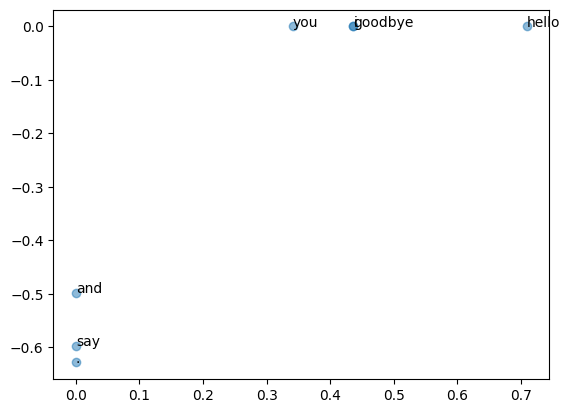

In [11]:
# 1. 调用 np.linalg.svd(W) 进行奇异值分解，它会返回三个矩阵，我们分别用 U, S, V 来接收。
#    其中 U 就是我们想要的稠密“单词空间”矩阵。
# 2. 我们要把维度降到 2 维（为了方便在二维平面上画图观察）。
#    请利用 NumPy 的切片操作，从矩阵 U 中取出所有行，但只保留前 2 列，存入变量 word_vecs 中。

U, S, V = np.linalg.svd(W)
word_vecs = U[:, 0:2]

# 遍历字典，把单词标注在对应的二维坐标上
for word, word_id in word_to_id.items():
    plt.annotate(word, (word_vecs[word_id, 0], word_vecs[word_id, 1]))

# 画出散点图
plt.scatter(word_vecs[:,0], word_vecs[:,1], alpha=0.5)
plt.show()

## 大规模语料与 Truncated SVD (截断奇异值分解)

面对真实的、动辄上万词汇量的自然语言语料（如 PTB 数据集），传统的 np.linalg.svd 因为 O(N3) 的计算复杂度会导致性能崩溃。

因此，在实际工程中，我们通常使用 sklearn 提供的 randomized_svd。它利用随机化算法，只去计算那些最大的、最重要的奇异值，不仅速度极快，而且直接达到了降维（抛弃微小奇异值/噪声）的目的。